# STUDIARE I NETWORK DI INTERAZIONE

### Facendo evolvere il sistema con open mindedness and moderate information, abbiamo visto che c'è una transizione di fase che permette di parlare di consenso.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import ternary
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
from mpl_toolkits.mplot3d import Axes3D
import networkx as nx
from Functions_OPEN_MINDEDNESS import *
from scipy.spatial.distance import pdist, squareform

In [2]:
PI = 0.5
K = 5
N = 100
mu = 200
I = external_info( K, 0.3 )
entropy_threshold = 1.3
eps = 0.1
time = 500
alpha = 0.01
pop_iniz = generate_population(K,N, entropy_threshold)
o = calculate_total_overlap(pop_iniz)      

In [3]:
pop_finale , storico , storico_int = evolve_population_with_info_and_peer_openm( pop_iniz , time , eps, alpha , I , PI , mu)

Il dizionario storico_interaction è fatto così : 
    storico_interaction[chi ha interagito][tempo di interazione] = [tipo di interazione ( 1 agree, -1 disagree , 'OM' ) ]

Comunità rilevate: 7


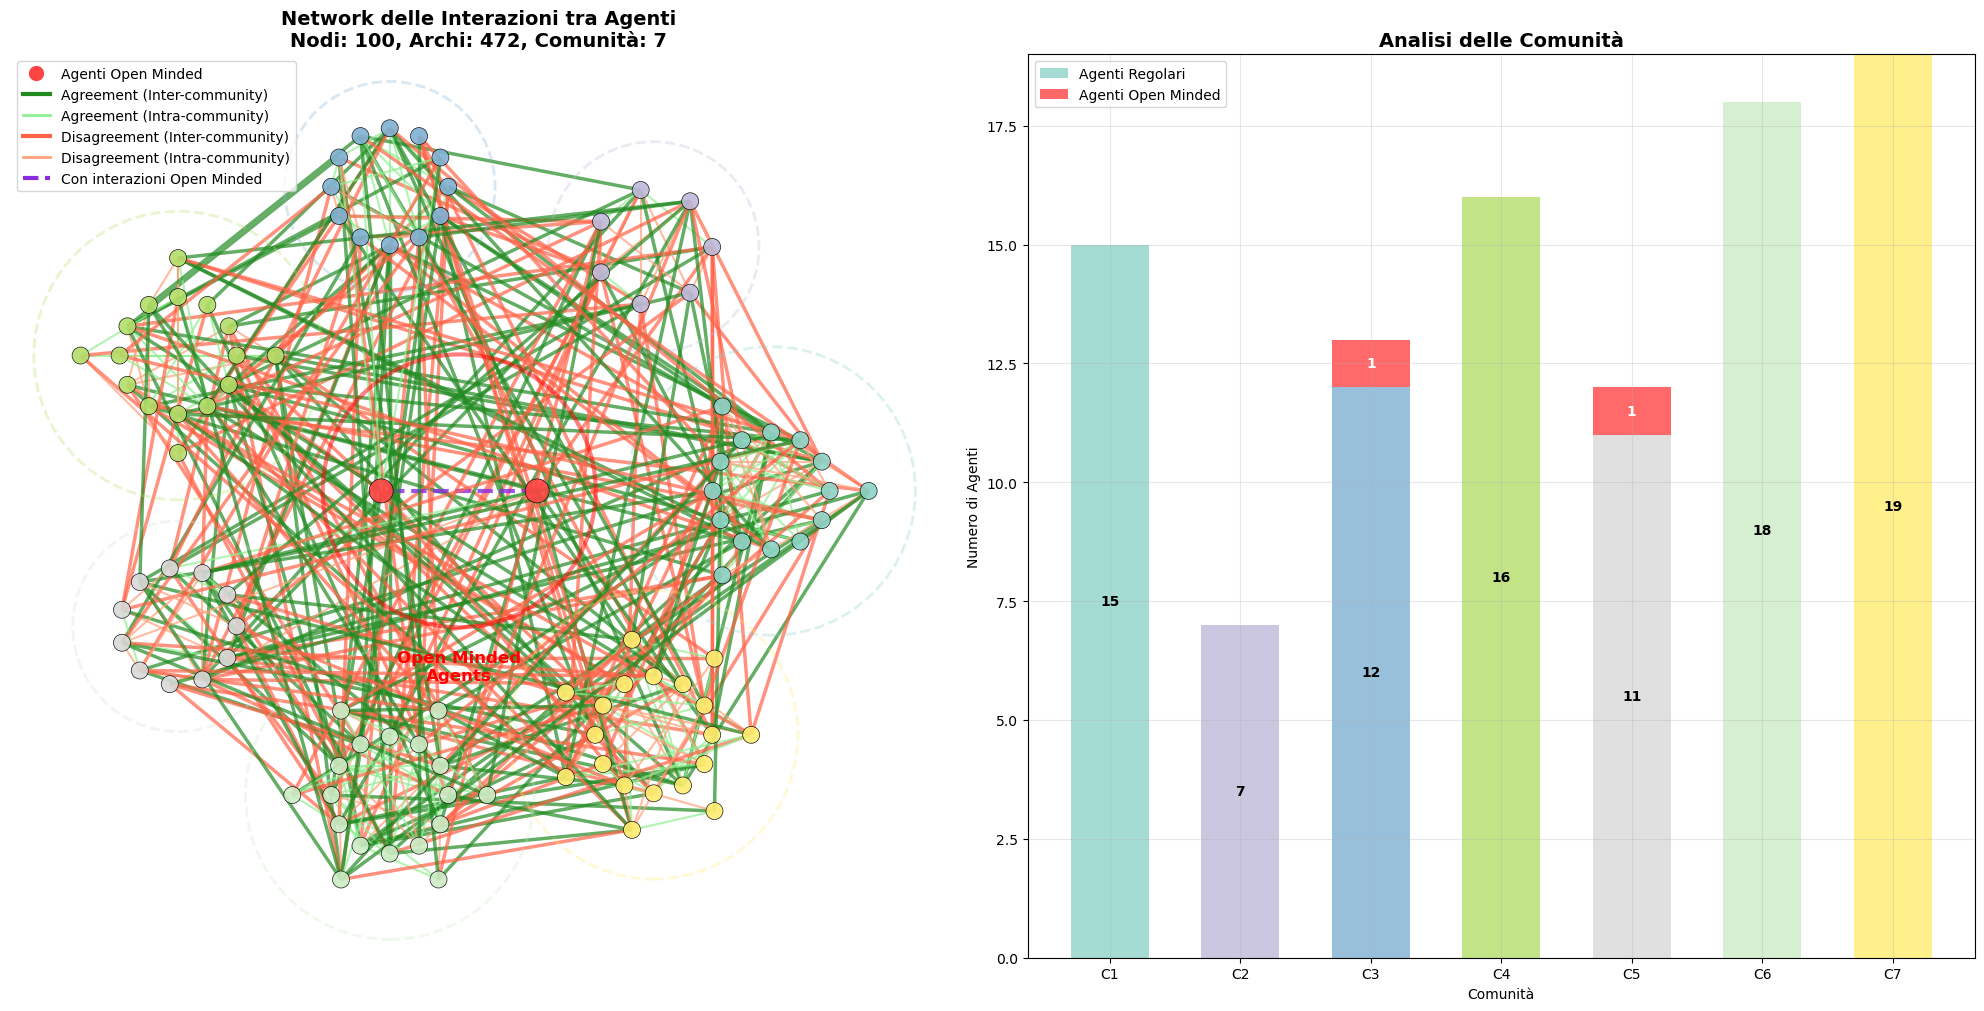


=== STATISTICHE DETTAGLIATE ===
Agenti open minded: 2 (2.0%)
Collegamenti intra-community: 207
Collegamenti inter-community: 265
Ratio inter/intra: 1.28

=== CENTRALITÀ AGENTI OPEN MINDED ===
Centralità di grado media - Open Minded: 0.081
Centralità di grado media - Regolari: 0.096
Centralità di betweenness media - Open Minded: 0.010
Centralità di betweenness media - Regolari: 0.013


In [4]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict



# Crea il grafo
G = nx.Graph()

# Set per tracciare gli agenti con interazioni "open minded"
open_minded_agents = set()

# Aggiungi nodi e archi
for agent1_id, time_dict in storico_int.items():
    for time, interaction_list in time_dict.items():
        for interaction in interaction_list:
            interaction_type, distance, agent2_id = interaction
            
            # Aggiungi nodi se non esistono
            G.add_node(agent1_id)
            G.add_node(agent2_id)
            
            # Traccia agenti open minded
            if interaction_type == 'om':
                open_minded_agents.add(agent1_id)
                open_minded_agents.add(agent2_id)
            
            # Aggiungi arco con attributi
            if G.has_edge(agent1_id, agent2_id):
                G[agent1_id][agent2_id]['interactions'].append({
                    'type': interaction_type,
                    'distance': distance,
                    'time': time
                })
            else:
                G.add_edge(agent1_id, agent2_id, interactions=[{
                    'type': interaction_type,
                    'distance': distance,
                    'time': time
                }])

# Analisi delle comunità
communities = nx.community.louvain_communities(G, seed=42)
print(f"Comunità rilevate: {len(communities)}")

# Mappa nodo -> comunità
node_community_map = {}
for i, community in enumerate(communities):
    for node in community:
        node_community_map[node] = i

# Layout personalizzato che mette gli open minded al centro
def create_custom_layout(G, communities, open_minded_agents):
    pos = {}
    
    # Parametri per il layout
    center_radius = 2.0  # Raggio del cerchio centrale per open minded
    community_radius = 8.0  # Raggio per le comunità
    nodes_per_ring = 12  # Nodi per anello nelle comunità
    
    # 1. Posiziona gli agenti open minded al centro in un cerchio
    om_agents = list(open_minded_agents)
    if om_agents:
        angles_om = np.linspace(0, 2*np.pi, len(om_agents), endpoint=False)
        for i, agent in enumerate(om_agents):
            pos[agent] = (center_radius * np.cos(angles_om[i]), 
                         center_radius * np.sin(angles_om[i]))
    
    # 2. Posiziona le comunità in cerchi attorno al centro
    community_angles = np.linspace(0, 2*np.pi, len(communities), endpoint=False)
    
    for comm_idx, community in enumerate(communities):
        # Agenti non open minded in questa comunità
        non_om_agents = [agent for agent in community if agent not in open_minded_agents]
        
        if not non_om_agents:
            continue
            
        # Centro della comunità
        comm_center_x = community_radius * np.cos(community_angles[comm_idx])
        comm_center_y = community_radius * np.sin(community_angles[comm_idx])
        
        # Disponi gli agenti della comunità in anelli concentrici
        agents_positioned = 0
        ring_radius = 1.5
        ring_number = 0
        
        while agents_positioned < len(non_om_agents):
            agents_in_this_ring = min(nodes_per_ring, len(non_om_agents) - agents_positioned)
            angles = np.linspace(0, 2*np.pi, agents_in_this_ring, endpoint=False)
            
            for i in range(agents_in_this_ring):
                agent = non_om_agents[agents_positioned + i]
                angle = angles[i]
                x = comm_center_x + ring_radius * np.cos(angle)
                y = comm_center_y + ring_radius * np.sin(angle)
                pos[agent] = (x, y)
            
            agents_positioned += agents_in_this_ring
            ring_number += 1
            ring_radius += 1.0
    
    return pos

# Crea il layout personalizzato
pos = create_custom_layout(G, communities, open_minded_agents)

# Prepara i colori
community_colors = plt.cm.Set3(np.linspace(0, 1, len(communities)))

# Colori dei nodi
node_colors = []
node_sizes = []
for node in G.nodes():
    if node in open_minded_agents:
        node_colors.append('#FF4444')  # Rosso brillante per open minded
        node_sizes.append(300)  # Più grandi
    else:
        community_idx = node_community_map.get(node, 0)
        node_colors.append(community_colors[community_idx])
        node_sizes.append(150)

# Analizza gli archi per tipo
edge_colors = []
edge_widths = []
edge_alphas = []

for edge in G.edges():
    interactions_on_edge = G[edge[0]][edge[1]]['interactions']
    agreement_count = sum(1 for i in interactions_on_edge if i['type'] == 1)
    disagreement_count = sum(1 for i in interactions_on_edge if i['type'] == -1)
    om_count = sum(1 for i in interactions_on_edge if i['type'] == 'om')
    
    # Determina se è inter o intra community
    comm1 = node_community_map.get(edge[0], -1)
    comm2 = node_community_map.get(edge[1], -1)
    is_inter_community = comm1 != comm2
    
    if om_count > 0:
        edge_colors.append('#8A2BE2')  # Viola per open minded
        edge_widths.append(3.0)
        edge_alphas.append(0.8)
    elif agreement_count > disagreement_count:
        if is_inter_community:
            edge_colors.append('#228B22')  # Verde scuro per agreement inter-community
            edge_widths.append(2.5)
        else:
            edge_colors.append('#90EE90')  # Verde chiaro per agreement intra-community
            edge_widths.append(1.5)
        edge_alphas.append(0.7)
    else:
        if is_inter_community:
            edge_colors.append('#FF6347')  # Rosso per disagreement inter-community
            edge_widths.append(2.5)
        else:
            edge_colors.append('#FFA07A')  # Rosso chiaro per disagreement intra-community
            edge_widths.append(1.5)
        edge_alphas.append(0.7)

# Visualizzazione principale
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Grafo principale
ax1.set_title("Network delle Interazioni tra Agenti\n" +
             f"Nodi: {G.number_of_nodes()}, Archi: {G.number_of_edges()}, " +
             f"Comunità: {len(communities)}", fontsize=14, fontweight='bold')

# Disegna i nodi
nx.draw_networkx_nodes(G, pos, ax=ax1,
                      node_color=node_colors,
                      node_size=node_sizes,
                      alpha=0.9,
                      edgecolors='black',
                      linewidths=0.5)

# Disegna gli archi
for i, edge in enumerate(G.edges()):
    style = '--' if any(inter['type'] == 'om' for inter in G[edge[0]][edge[1]]['interactions']) else '-'
    nx.draw_networkx_edges(G, pos, ax=ax1,
                          edgelist=[edge],
                          edge_color=edge_colors[i],
                          width=edge_widths[i],
                          alpha=edge_alphas[i],
                          style=style)

# Evidenzia le comunità con cerchi
for i, community in enumerate(communities):
    non_om_in_comm = [node for node in community if node not in open_minded_agents]
    if non_om_in_comm:
        # Calcola il bounding box della comunità
        comm_positions = [pos[node] for node in non_om_in_comm]
        if comm_positions:
            xs, ys = zip(*comm_positions)
            center_x, center_y = np.mean(xs), np.mean(ys)
            max_dist = max(np.sqrt((x-center_x)**2 + (y-center_y)**2) for x, y in comm_positions)
            
            circle = plt.Circle((center_x, center_y), max_dist + 1.2, 
                              fill=False, color=community_colors[i], 
                              linewidth=2, alpha=0.3, linestyle='--')
            ax1.add_patch(circle)

# Cerchio per agenti open minded
if open_minded_agents:
    om_circle = plt.Circle((0, 0), 3.5, fill=False, color='red', 
                          linewidth=3, alpha=0.5, linestyle='-')
    ax1.add_patch(om_circle)
    ax1.text(0, -4.5, 'Open Minded\nAgents', ha='center', va='center', 
            fontsize=12, fontweight='bold', color='red')

ax1.set_aspect('equal')
ax1.axis('off')

# Legenda
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF4444', 
               markersize=12, label='Agenti Open Minded'),
    plt.Line2D([0], [0], color='#228B22', linewidth=3, label='Agreement (Inter-community)'),
    plt.Line2D([0], [0], color='#90EE90', linewidth=2, label='Agreement (Intra-community)'),
    plt.Line2D([0], [0], color='#FF6347', linewidth=3, label='Disagreement (Inter-community)'),
    plt.Line2D([0], [0], color='#FFA07A', linewidth=2, label='Disagreement (Intra-community)'),
    plt.Line2D([0], [0], color='#8A2BE2', linewidth=3, linestyle='--', 
               label='Con interazioni Open Minded')
]
ax1.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0, 1))

# Grafico delle statistiche delle comunità
ax2.set_title("Analisi delle Comunità", fontsize=14, fontweight='bold')

comm_sizes = [len(comm) for comm in communities]
om_in_comms = [len([node for node in comm if node in open_minded_agents]) for comm in communities]
regular_in_comms = [size - om for size, om in zip(comm_sizes, om_in_comms)]

x = range(len(communities))
width = 0.6

bars1 = ax2.bar(x, regular_in_comms, width, label='Agenti Regolari', 
                color=[community_colors[i] for i in range(len(communities))], alpha=0.8)
bars2 = ax2.bar(x, om_in_comms, width, bottom=regular_in_comms, 
                label='Agenti Open Minded', color='#FF4444', alpha=0.8)

ax2.set_xlabel('Comunità')
ax2.set_ylabel('Numero di Agenti')
ax2.set_xticks(x)
ax2.set_xticklabels([f'C{i+1}' for i in range(len(communities))])
ax2.legend()
ax2.grid(True, alpha=0.3)

# Aggiungi etichette sui bar
for i, (regular, om) in enumerate(zip(regular_in_comms, om_in_comms)):
    if regular > 0:
        ax2.text(i, regular/2, str(regular), ha='center', va='center', fontweight='bold')
    if om > 0:
        ax2.text(i, regular + om/2, str(om), ha='center', va='center', 
                fontweight='bold', color='white')

plt.tight_layout()
plt.show()

# Statistiche dettagliate
print("\n=== STATISTICHE DETTAGLIATE ===")
print(f"Agenti open minded: {len(open_minded_agents)} ({len(open_minded_agents)/G.number_of_nodes()*100:.1f}%)")

# Analisi collegamenti inter vs intra community
inter_community_edges = 0
intra_community_edges = 0

for edge in G.edges():
    comm1 = node_community_map.get(edge[0], -1)
    comm2 = node_community_map.get(edge[1], -1)
    if comm1 != comm2:
        inter_community_edges += 1
    else:
        intra_community_edges += 1

print(f"Collegamenti intra-community: {intra_community_edges}")
print(f"Collegamenti inter-community: {inter_community_edges}")
print(f"Ratio inter/intra: {inter_community_edges/intra_community_edges:.2f}")

# Centralità degli agenti open minded
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)

print(f"\n=== CENTRALITÀ AGENTI OPEN MINDED ===")
om_degree_avg = np.mean([degree_centrality[agent] for agent in open_minded_agents])
regular_degree_avg = np.mean([degree_centrality[agent] for agent in G.nodes() if agent not in open_minded_agents])

print(f"Centralità di grado media - Open Minded: {om_degree_avg:.3f}")
print(f"Centralità di grado media - Regolari: {regular_degree_avg:.3f}")

om_between_avg = np.mean([betweenness_centrality[agent] for agent in open_minded_agents])
regular_between_avg = np.mean([betweenness_centrality[agent] for agent in G.nodes() if agent not in open_minded_agents])

print(f"Centralità di betweenness media - Open Minded: {om_between_avg:.3f}")
print(f"Centralità di betweenness media - Regolari: {regular_between_avg:.3f}")

Inizio analisi parametrica...
Parametri 'a': [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Entropy thresholds: [1.4 1.6 1.8 2.  2.2 2.4]

Simulazione: a=0.10, entropy_threshold=1.40
  -> OM percentage: 7.7%
Simulazione: a=0.20, entropy_threshold=1.40
  -> OM percentage: 5.3%
Simulazione: a=0.30, entropy_threshold=1.40
  -> OM percentage: 4.0%
Simulazione: a=0.40, entropy_threshold=1.40
  -> OM percentage: 4.0%
Simulazione: a=0.50, entropy_threshold=1.40
  -> OM percentage: 10.0%
Simulazione: a=0.60, entropy_threshold=1.40
  -> OM percentage: 4.7%
Simulazione: a=0.70, entropy_threshold=1.40
  -> OM percentage: 6.3%
Simulazione: a=0.80, entropy_threshold=1.40
  -> OM percentage: 7.0%
Simulazione: a=0.90, entropy_threshold=1.40
  -> OM percentage: 6.7%
Simulazione: a=1.00, entropy_threshold=1.40
  -> OM percentage: 3.7%
Simulazione: a=0.10, entropy_threshold=1.60
  -> OM percentage: 4.0%
Simulazione: a=0.20, entropy_threshold=1.60
  -> OM percentage: 5.7%
Simulazione: a=0.30, entropy_threshol

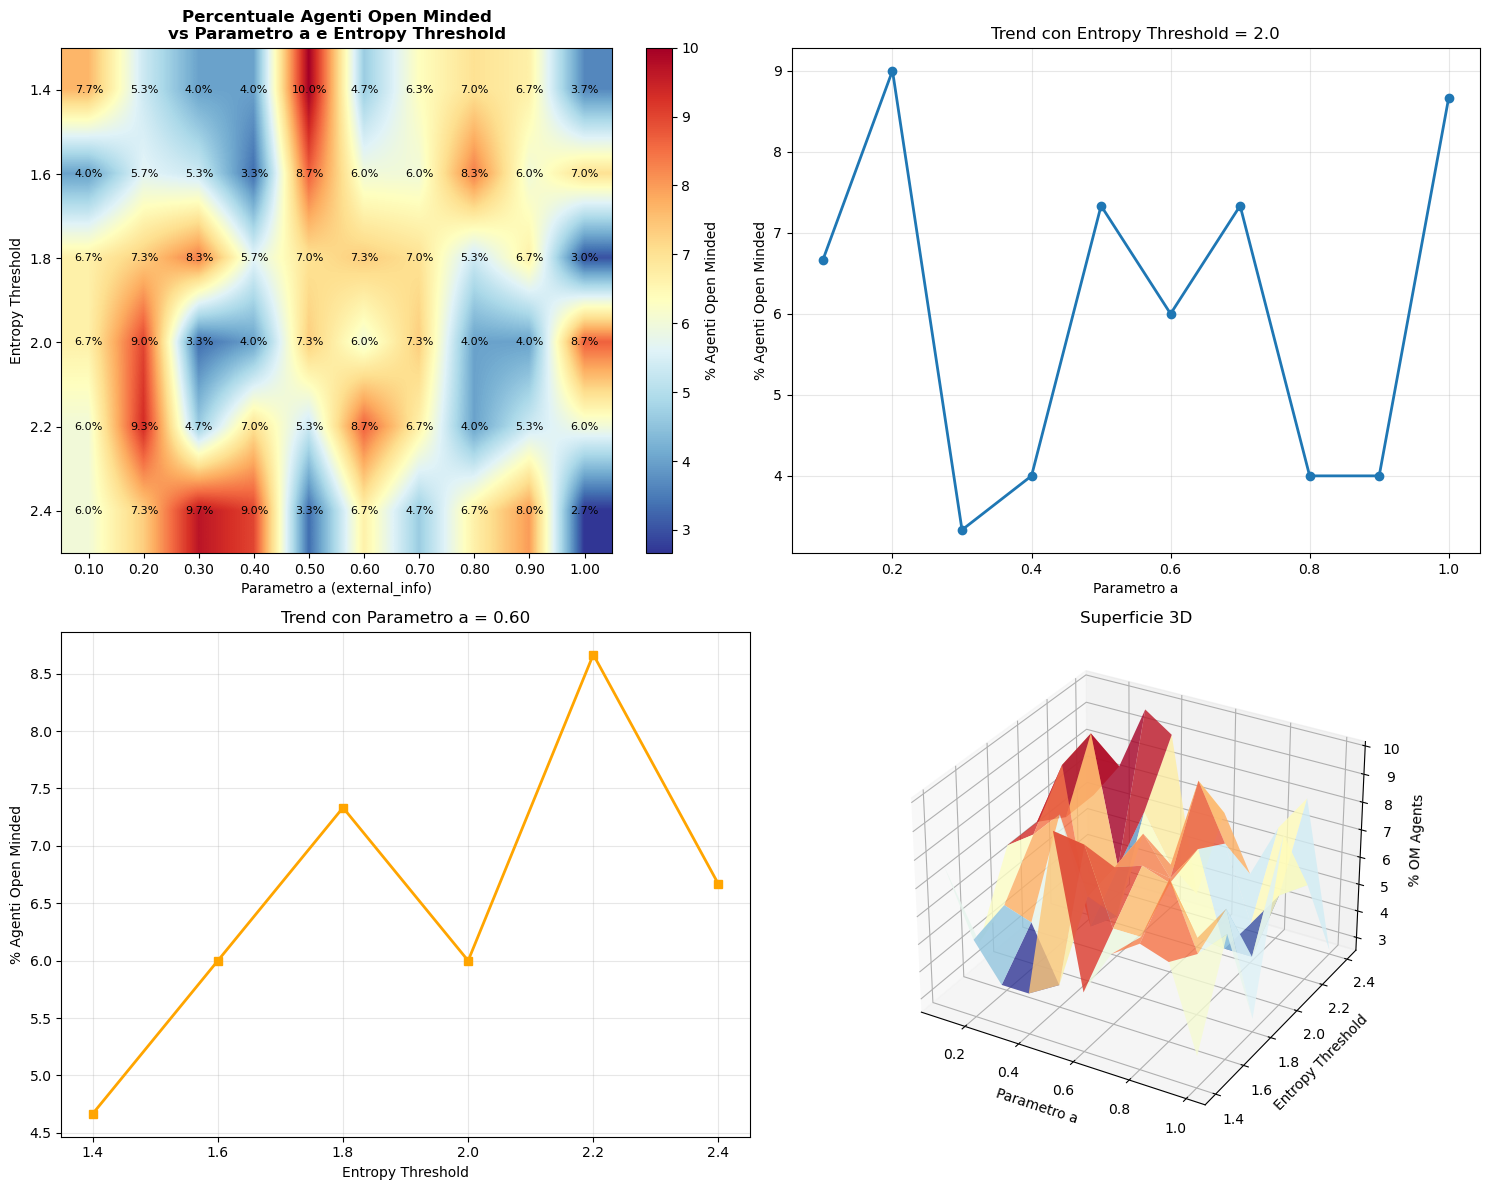

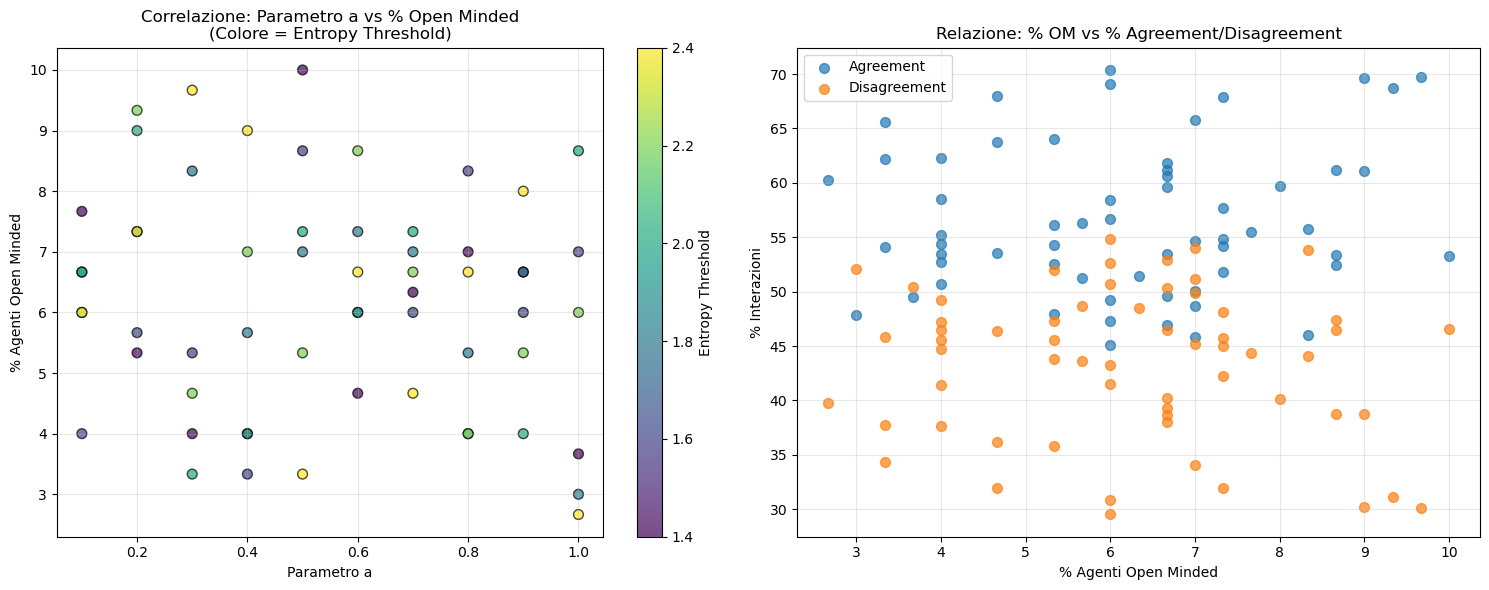


RIASSUNTO ANALISI PARAMETRICA
MASSIMO % Open Minded: 10.0%
  Parametri: a=0.50, entropy_threshold=1.4
  Agreement: 53.3%
  Disagreement: 46.6%

MINIMO % Open Minded: 2.7%
  Parametri: a=1.00, entropy_threshold=2.4
  Agreement: 60.2%
  Disagreement: 39.7%

CORRELAZIONI:
  Parametro a vs % OM: -0.149
  Entropy threshold vs % OM: 0.074


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import ast

def analyze_interactions_data(storico_int):
    """Analizza i dati delle interazioni e restituisce statistiche"""
    open_minded_agents = set()
    total_interactions = 0
    agreement_count = 0
    disagreement_count = 0
    om_count = 0
    all_agents = set()
    
    for agent1_id, time_dict in storico_int.items():
        all_agents.add(agent1_id)
        for time, interaction_list in time_dict.items():
            for interaction in interaction_list:
                interaction_type, distance, agent2_id = interaction
                all_agents.add(agent2_id)
                total_interactions += 1
                
                if interaction_type == 'om':
                    open_minded_agents.add(agent1_id)
                    open_minded_agents.add(agent2_id)
                    om_count += 1
                elif interaction_type == 1:
                    agreement_count += 1
                elif interaction_type == -1:
                    disagreement_count += 1
    
    om_percentage = len(open_minded_agents) / len(all_agents) * 100 if all_agents else 0
    
    return {
        'om_percentage': om_percentage,
        'om_count': len(open_minded_agents),
        'total_agents': len(all_agents),
        'total_interactions': total_interactions,
        'agreement_perc': agreement_count / total_interactions * 100 if total_interactions > 0 else 0,
        'disagreement_perc': disagreement_count / total_interactions * 100 if total_interactions > 0 else 0,
        'om_interactions_perc': om_count / total_interactions * 100 if total_interactions > 0 else 0
    }

def run_simulation(a_param, entropy_threshold):
    """

    """
    # Parametri fissi
    PI = 0.5
    K = 5
    N = 300
    mu = 200
    eps = 0.1
    time = 10000
    alpha = 0.0167
  
    I = external_info(K, a_param)
    pop_iniz = generate_population(K, N, entropy_threshold)
    o = calculate_total_overlap(pop_iniz)
    pop_finale, storico, storico_int = evolve_population_with_info_and_peer_openm(
    pop_iniz, time, eps, alpha, I, PI, mu)
    
    
    return storico_int

def parametric_analysis():
    """Esegue l'analisi parametrica completa"""
    
    # Range dei parametri
    a_values = np.linspace(0.1, 1.0, 10)  # Parametro 'a' in external_info
    entropy_values = np.linspace(1.4, 2.4, 6)  # entropy_threshold
    
    # Matrice per i risultati
    results = np.zeros((len(entropy_values), len(a_values)))
    detailed_results = {}
    
    print("Inizio analisi parametrica...")
    print(f"Parametri 'a': {a_values}")
    print(f"Entropy thresholds: {entropy_values}")
    print()
    
    for i, entropy_thresh in enumerate(entropy_values):
        for j, a_param in enumerate(a_values):
            print(f"Simulazione: a={a_param:.2f}, entropy_threshold={entropy_thresh:.2f}")
            
            # Esegui simulazione
            storico_int = run_simulation(a_param, entropy_thresh)
            
            # Analizza risultati
            stats = analyze_interactions_data(storico_int)
            results[i, j] = stats['om_percentage']
            
            # Salva dettagli
            detailed_results[(entropy_thresh, a_param)] = stats
            
            print(f"  -> OM percentage: {stats['om_percentage']:.1f}%")
    
    return results, detailed_results, a_values, entropy_values

def plot_results(results, detailed_results, a_values, entropy_values):
    """Crea visualizzazioni dei risultati"""
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Heatmap principale
    im1 = ax1.imshow(results, cmap='RdYlBu_r', aspect='auto', interpolation='bilinear')
    ax1.set_title('Percentuale Agenti Open Minded\nvs Parametro a e Entropy Threshold', 
                  fontweight='bold', fontsize=12)
    ax1.set_xlabel('Parametro a (external_info)')
    ax1.set_ylabel('Entropy Threshold')
    
    # Aggiungi valori sulle celle
    for i in range(len(entropy_values)):
        for j in range(len(a_values)):
            text = ax1.text(j, i, f'{results[i, j]:.1f}%', 
                           ha="center", va="center", color="black", fontsize=8)
    
    # Imposta tick labels
    ax1.set_xticks(range(len(a_values)))
    ax1.set_xticklabels([f'{a:.2f}' for a in a_values])
    ax1.set_yticks(range(len(entropy_values)))
    ax1.set_yticklabels([f'{e:.1f}' for e in entropy_values])
    
    # Colorbar
    cbar1 = plt.colorbar(im1, ax=ax1)
    cbar1.set_label('% Agenti Open Minded')
    
    # 2. Trend per entropy_threshold fisso (intermedio)
    mid_entropy_idx = len(entropy_values) // 2
    mid_entropy = entropy_values[mid_entropy_idx]
    ax2.plot(a_values, results[mid_entropy_idx, :], 'o-', linewidth=2, markersize=6)
    ax2.set_title(f'Trend con Entropy Threshold = {mid_entropy:.1f}')
    ax2.set_xlabel('Parametro a')
    ax2.set_ylabel('% Agenti Open Minded')
    ax2.grid(True, alpha=0.3)
    
    # 3. Trend per parametro 'a' fisso (intermedio)
    mid_a_idx = len(a_values) // 2
    mid_a = a_values[mid_a_idx]
    ax3.plot(entropy_values, results[:, mid_a_idx], 's-', linewidth=2, markersize=6, color='orange')
    ax3.set_title(f'Trend con Parametro a = {mid_a:.2f}')
    ax3.set_xlabel('Entropy Threshold')
    ax3.set_ylabel('% Agenti Open Minded')
    ax3.grid(True, alpha=0.3)
    
    # 4. Superficie 3D
    from mpl_toolkits.mplot3d import Axes3D
    ax4.remove()
    ax4 = fig.add_subplot(2, 2, 4, projection='3d')
    
    A, E = np.meshgrid(a_values, entropy_values)
    surf = ax4.plot_surface(A, E, results, cmap='RdYlBu_r', alpha=0.8)
    ax4.set_title('Superficie 3D')
    ax4.set_xlabel('Parametro a')
    ax4.set_ylabel('Entropy Threshold')
    ax4.set_zlabel('% OM Agents')
    
    plt.tight_layout()
    plt.show()
    
    # Grafico aggiuntivo: correlazioni
    fig2, (ax5, ax6) = plt.subplots(1, 2, figsize=(15, 6))
    
    # 5. Scatter plot di tutte le combinazioni
    all_a = []
    all_entropy = []
    all_om = []
    all_agreements = []
    all_disagreements = []
    
    for (entropy_thresh, a_param), stats in detailed_results.items():
        all_a.append(a_param)
        all_entropy.append(entropy_thresh)
        all_om.append(stats['om_percentage'])
        all_agreements.append(stats['agreement_perc'])
        all_disagreements.append(stats['disagreement_perc'])
    
    scatter = ax5.scatter(all_a, all_om, c=all_entropy, cmap='viridis', 
                         s=50, alpha=0.7, edgecolors='black')
    ax5.set_title('Correlazione: Parametro a vs % Open Minded\n(Colore = Entropy Threshold)')
    ax5.set_xlabel('Parametro a')
    ax5.set_ylabel('% Agenti Open Minded')
    ax5.grid(True, alpha=0.3)
    cbar2 = plt.colorbar(scatter, ax=ax5)
    cbar2.set_label('Entropy Threshold')
    
    # 6. Relazione tra OM e Agreement/Disagreement
    ax6.scatter(all_om, all_agreements, label='Agreement', alpha=0.7, s=50)
    ax6.scatter(all_om, all_disagreements, label='Disagreement', alpha=0.7, s=50)
    ax6.set_title('Relazione: % OM vs % Agreement/Disagreement')
    ax6.set_xlabel('% Agenti Open Minded')
    ax6.set_ylabel('% Interazioni')
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def print_summary(detailed_results, a_values, entropy_values):
    """Stampa un riassunto dei risultati"""
    print("\n" + "="*60)
    print("RIASSUNTO ANALISI PARAMETRICA")
    print("="*60)
    
    # Trova i casi estremi
    max_om = max(stats['om_percentage'] for stats in detailed_results.values())
    min_om = min(stats['om_percentage'] for stats in detailed_results.values())
    
    max_case = [(params, stats) for params, stats in detailed_results.items() 
                if stats['om_percentage'] == max_om][0]
    min_case = [(params, stats) for params, stats in detailed_results.items() 
                if stats['om_percentage'] == min_om][0]
    
    print(f"MASSIMO % Open Minded: {max_om:.1f}%")
    print(f"  Parametri: a={max_case[0][1]:.2f}, entropy_threshold={max_case[0][0]:.1f}")
    print(f"  Agreement: {max_case[1]['agreement_perc']:.1f}%")
    print(f"  Disagreement: {max_case[1]['disagreement_perc']:.1f}%")
    print()
    
    print(f"MINIMO % Open Minded: {min_om:.1f}%")
    print(f"  Parametri: a={min_case[0][1]:.2f}, entropy_threshold={min_case[0][0]:.1f}")
    print(f"  Agreement: {min_case[1]['agreement_perc']:.1f}%")
    print(f"  Disagreement: {min_case[1]['disagreement_perc']:.1f}%")
    print()
    
    # Correlazioni approssimate
    all_a = [params[1] for params in detailed_results.keys()]
    all_entropy = [params[0] for params in detailed_results.keys()]
    all_om = [stats['om_percentage'] for stats in detailed_results.values()]
    
    corr_a_om = np.corrcoef(all_a, all_om)[0, 1]
    corr_entropy_om = np.corrcoef(all_entropy, all_om)[0, 1]
    
    print(f"CORRELAZIONI:")
    print(f"  Parametro a vs % OM: {corr_a_om:.3f}")
    print(f"  Entropy threshold vs % OM: {corr_entropy_om:.3f}")

# Esegui l'analisi completa
if __name__ == "__main__":
    
    results, detailed_results, a_values, entropy_values = parametric_analysis()
    plot_results(results, detailed_results, a_values, entropy_values)
    print_summary(detailed_results, a_values, entropy_values)

# Fino ad ora avevamo considerato le interazioni open minded come  OM = ne hai avuta almeno una nel tuo storico, ora provo ad analizzare con un parametro dinamico 


Inizio analisi parametrica...
Parametri 'a': [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Entropy thresholds: [1.4 1.6 1.8 2.  2.2 2.4]

Simulazione: a=0.10, entropy_threshold=1.40
  -> System OM score: 0.0% (std: 0.3)
Simulazione: a=0.20, entropy_threshold=1.40
  -> System OM score: 0.1% (std: 0.4)
Simulazione: a=0.30, entropy_threshold=1.40
  -> System OM score: 0.1% (std: 0.4)
Simulazione: a=0.40, entropy_threshold=1.40
  -> System OM score: 0.2% (std: 0.5)
Simulazione: a=0.50, entropy_threshold=1.40
  -> System OM score: 0.1% (std: 0.3)
Simulazione: a=0.60, entropy_threshold=1.40
  -> System OM score: 0.1% (std: 0.4)
Simulazione: a=0.70, entropy_threshold=1.40
  -> System OM score: 0.1% (std: 0.3)
Simulazione: a=0.80, entropy_threshold=1.40
  -> System OM score: 0.1% (std: 0.3)
Simulazione: a=0.90, entropy_threshold=1.40
  -> System OM score: 0.1% (std: 0.4)
Simulazione: a=1.00, entropy_threshold=1.40
  -> System OM score: 0.1% (std: 0.3)
Simulazione: a=0.10, entropy_threshold=1.60
  

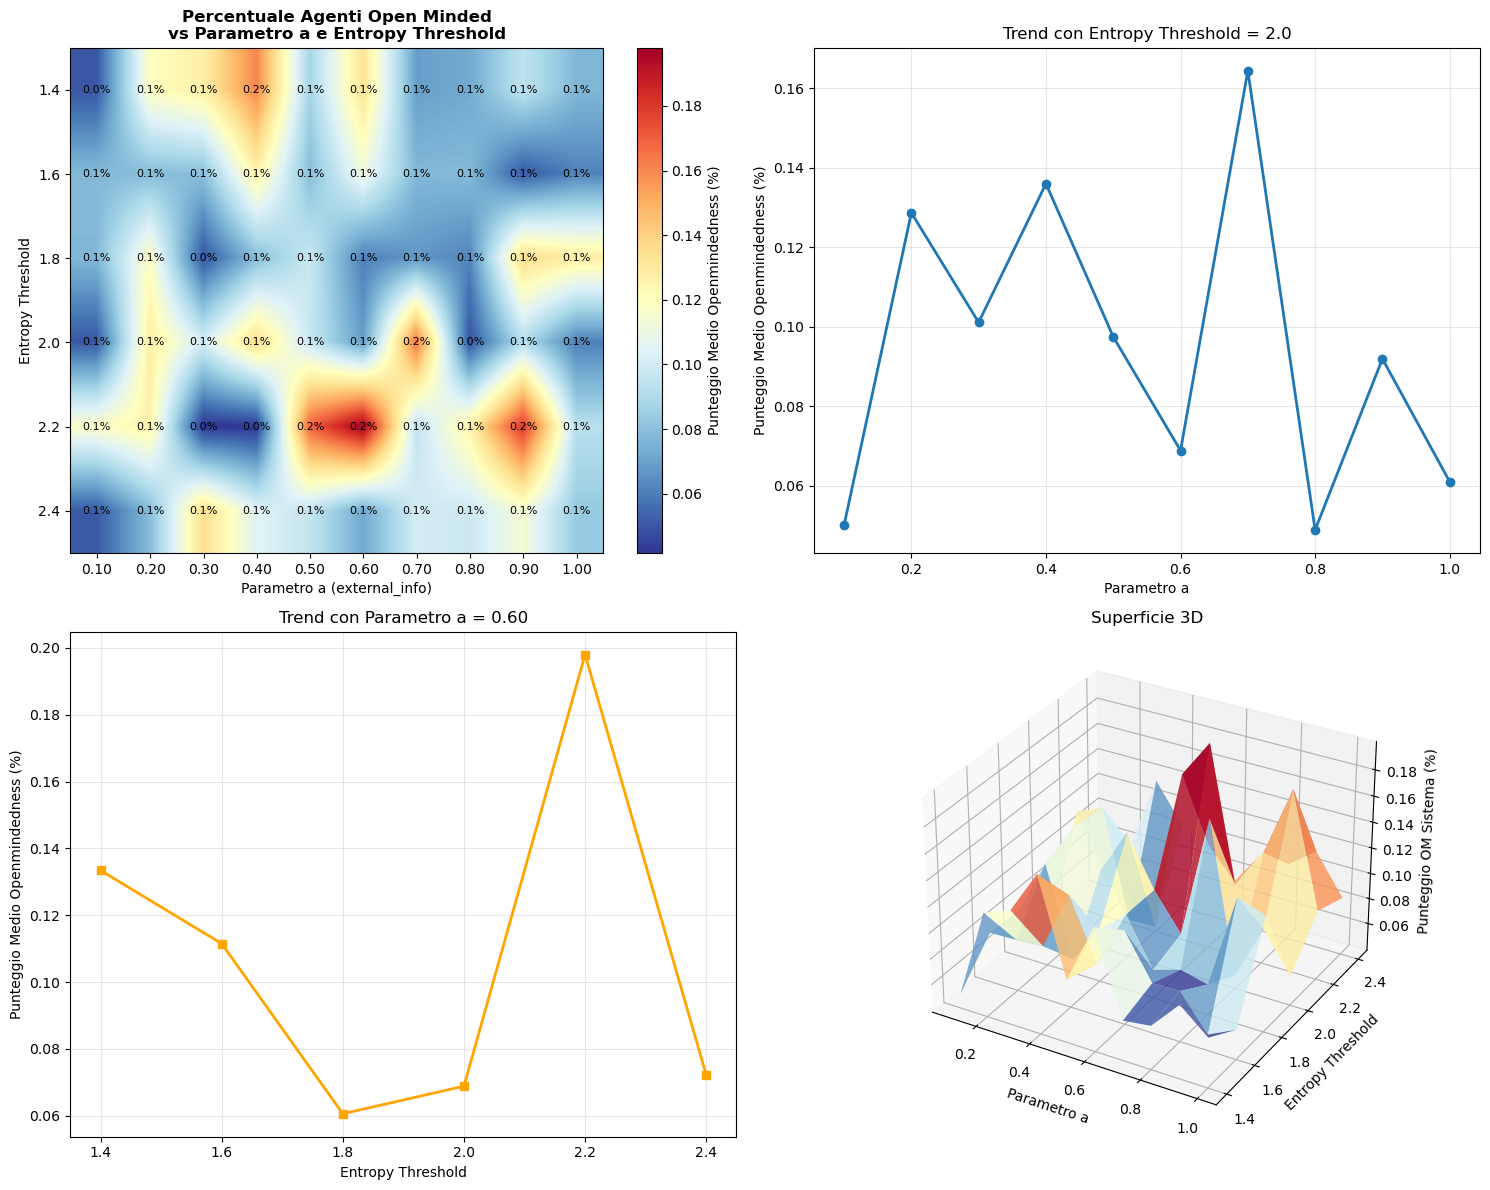

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


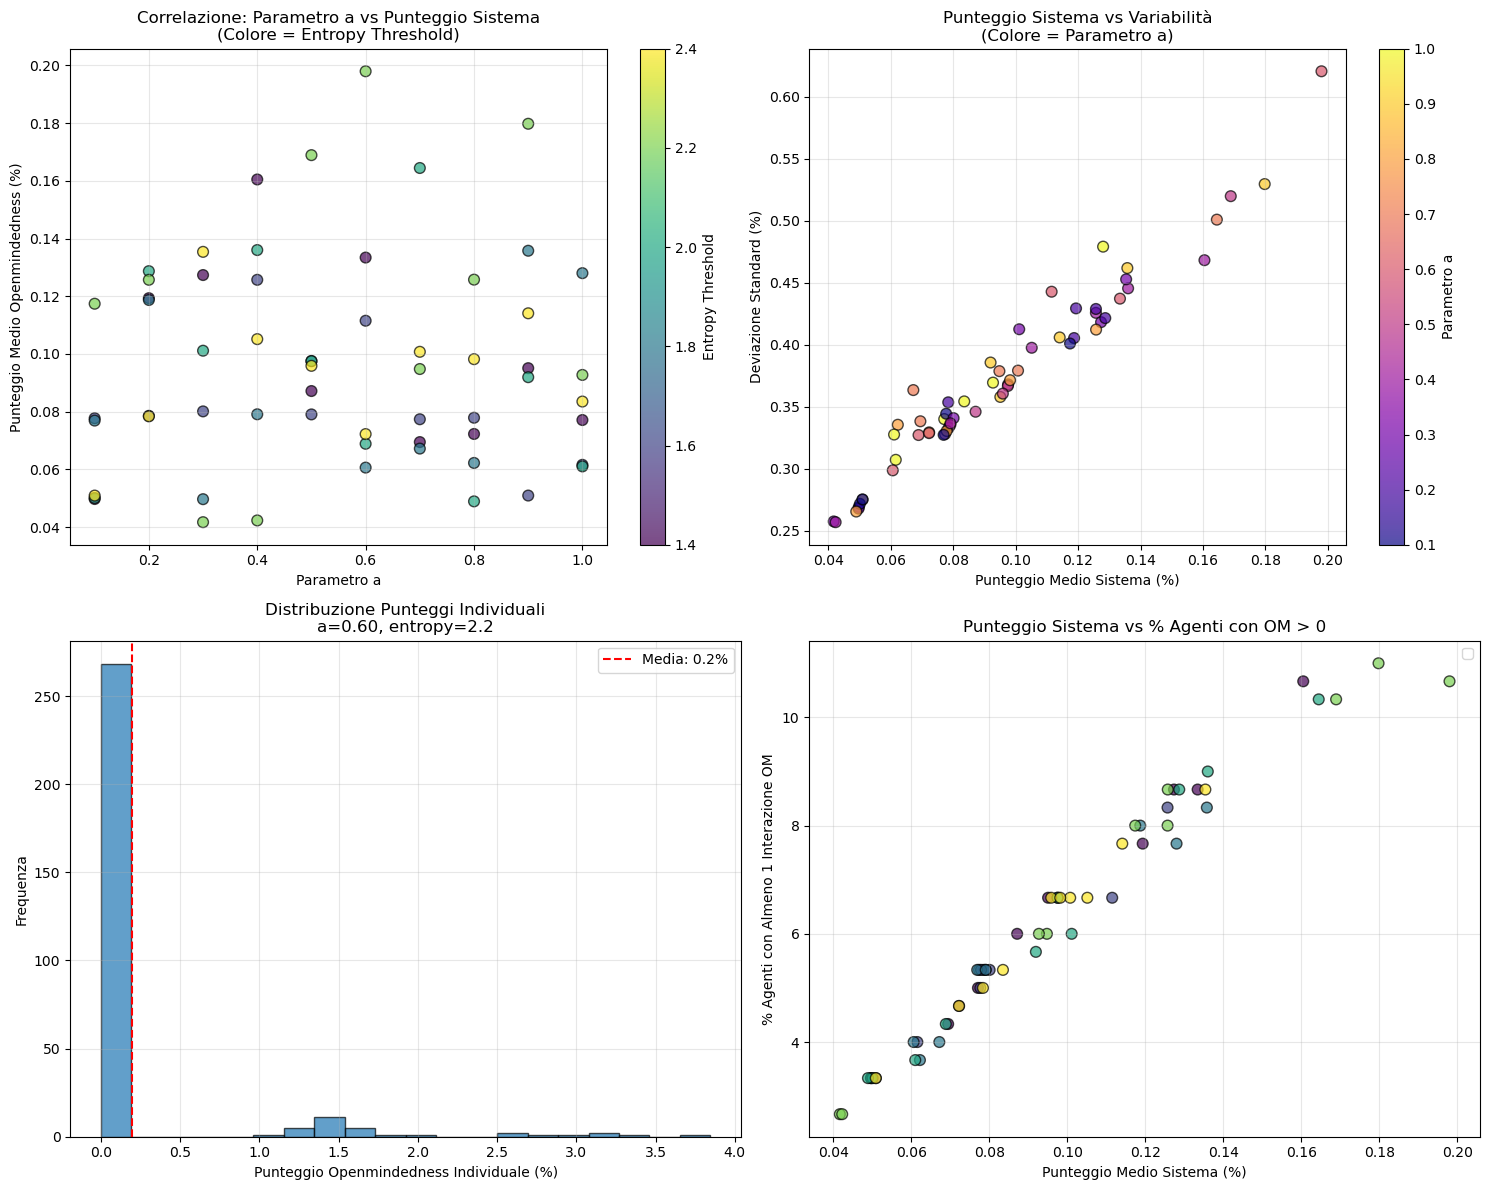


RIASSUNTO ANALISI PARAMETRICA
MASSIMO Punteggio Sistema: 0.2%
  Parametri: a=0.60, entropy_threshold=2.2
  Deviazione Standard: 0.6%
  Mediana: 0.0%
  Agenti con OM>0: 32/300 (10.7%)

MINIMO Punteggio Sistema: 0.0%
  Parametri: a=0.30, entropy_threshold=2.2
  Deviazione Standard: 0.3%
  Mediana: 0.0%
  Agenti con OM>0: 8/300 (2.7%)

CORRELAZIONI:
  Parametro a vs Punteggio Sistema: 0.033
  Entropy threshold vs Punteggio Sistema: 0.122
  Punteggio Sistema vs Variabilità: 0.975

DISTRIBUZIONE PUNTEGGI SISTEMA:
  Media: 0.1%
  Mediana: 0.1%
  Dev. Standard: 0.0%
  Range: 0.0% - 0.2%


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import ast

def analyze_interactions_data(storico_int):
    """Analizza i dati delle interazioni e calcola punteggi di openmindedness continui"""
    
    # Dizionari per tracciare le interazioni per agente
    agent_interactions = defaultdict(lambda: {'om': 0, 'agreement': 0, 'disagreement': 0, 'total': 0})
    total_interactions = 0
    agreement_count = 0
    disagreement_count = 0
    om_count = 0
    all_agents = set()
    
    # Conta tutte le interazioni per agente
    for agent1_id, time_dict in storico_int.items():
        all_agents.add(agent1_id)
        for time, interaction_list in time_dict.items():
            for interaction in interaction_list:
                interaction_type, distance, agent2_id = interaction
                all_agents.add(agent2_id)
                total_interactions += 1
                
                # Conta per entrambi gli agenti coinvolti
                for agent in [agent1_id, agent2_id]:
                    agent_interactions[agent]['total'] += 1
                    
                    if interaction_type == 'om':
                        agent_interactions[agent]['om'] += 1
                    elif interaction_type == 1:
                        agent_interactions[agent]['agreement'] += 1
                    elif interaction_type == -1:
                        agent_interactions[agent]['disagreement'] += 1
                
                # Conta globali
                if interaction_type == 'om':
                    om_count += 1
                elif interaction_type == 1:
                    agreement_count += 1
                elif interaction_type == -1:
                    disagreement_count += 1
    
    # Calcola punteggi di openmindedness per ogni agente
    openmindedness_scores = {}
    for agent in all_agents:
        if agent_interactions[agent]['total'] > 0:
            # Punteggio = (interazioni OM) / (totale interazioni) * 100
            score = (agent_interactions[agent]['om'] / agent_interactions[agent]['total']) * 100
            openmindedness_scores[agent] = score
        else:
            openmindedness_scores[agent] = 0.0
    
    # Media del sistema = media dei punteggi individuali
    system_openmindedness = np.mean(list(openmindedness_scores.values())) if openmindedness_scores else 0.0
    
    # Statistiche aggiuntive
    om_std = np.std(list(openmindedness_scores.values())) if openmindedness_scores else 0.0
    om_median = np.median(list(openmindedness_scores.values())) if openmindedness_scores else 0.0
    
    # Agenti con score > 0 (hanno avuto almeno una interazione OM)
    agents_with_om = len([score for score in openmindedness_scores.values() if score > 0])
    
    return {
        'system_openmindedness': system_openmindedness,
        'om_std': om_std,
        'om_median': om_median,
        'openmindedness_scores': openmindedness_scores,
        'agents_with_om': agents_with_om,
        'total_agents': len(all_agents),
        'total_interactions': total_interactions,
        'agreement_perc': agreement_count / total_interactions * 100 if total_interactions > 0 else 0,
        'disagreement_perc': disagreement_count / total_interactions * 100 if total_interactions > 0 else 0,
        'om_interactions_perc': om_count / total_interactions * 100 if total_interactions > 0 else 0,
        'agent_interactions': dict(agent_interactions)
    }

def run_simulation(a_param, entropy_threshold):
    """
    Simula una singola configurazione di parametri
    SOSTITUISCI QUESTA FUNZIONE CON IL TUO CODICE DI SIMULAZIONE
    """
    # Parametri fissi
    PI = 0.5
    K = 5
    N = 300
    mu = 200
    eps = 0.1
    time = 10000
    alpha = 0.0167
    
    I = external_info(K, a_param)
    pop_iniz = generate_population(K, N, entropy_threshold)
    o = calculate_total_overlap(pop_iniz)
    pop_finale, storico, storico_int = evolve_population_with_info_and_peer_openm(pop_iniz, time, eps, alpha, I, PI, mu)
    
    
    return storico_int

def parametric_analysis():
    """Esegue l'analisi parametrica completa"""
    
    # Range dei parametri
    a_values = np.linspace(0.1, 1.0, 10)  # Parametro 'a' in external_info
    entropy_values = np.linspace(1.4, 2.4, 6)  # entropy_threshold
    
    # Matrice per i risultati
    results = np.zeros((len(entropy_values), len(a_values)))
    detailed_results = {}
    
    print("Inizio analisi parametrica...")
    print(f"Parametri 'a': {a_values}")
    print(f"Entropy thresholds: {entropy_values}")
    print()
    
    for i, entropy_thresh in enumerate(entropy_values):
        for j, a_param in enumerate(a_values):
            print(f"Simulazione: a={a_param:.2f}, entropy_threshold={entropy_thresh:.2f}")
            
            # Esegui simulazione
            storico_int = run_simulation(a_param, entropy_thresh)
            
            # Analizza risultati
            stats = analyze_interactions_data(storico_int)
            results[i, j] = stats['system_openmindedness']
            
            # Salva dettagli
            detailed_results[(entropy_thresh, a_param)] = stats
            
            print(f"  -> System OM score: {stats['system_openmindedness']:.1f}% (std: {stats['om_std']:.1f})")
    
    return results, detailed_results, a_values, entropy_values

def plot_results(results, detailed_results, a_values, entropy_values):
    """Crea visualizzazioni dei risultati"""
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Heatmap principale
    im1 = ax1.imshow(results, cmap='RdYlBu_r', aspect='auto', interpolation='bilinear')
    ax1.set_title('Percentuale Agenti Open Minded\nvs Parametro a e Entropy Threshold', 
                  fontweight='bold', fontsize=12)
    ax1.set_xlabel('Parametro a (external_info)')
    ax1.set_ylabel('Entropy Threshold')
    
    # Aggiungi valori sulle celle
    for i in range(len(entropy_values)):
        for j in range(len(a_values)):
            text = ax1.text(j, i, f'{results[i, j]:.1f}%', 
                           ha="center", va="center", color="black", fontsize=8)
    
    # Imposta tick labels
    ax1.set_xticks(range(len(a_values)))
    ax1.set_xticklabels([f'{a:.2f}' for a in a_values])
    ax1.set_yticks(range(len(entropy_values)))
    ax1.set_yticklabels([f'{e:.1f}' for e in entropy_values])
    
    # Colorbar
    cbar1 = plt.colorbar(im1, ax=ax1)
    cbar1.set_label('Punteggio Medio Openmindedness (%)')
    
    # 2. Trend per entropy_threshold fisso (intermedio)
    mid_entropy_idx = len(entropy_values) // 2
    mid_entropy = entropy_values[mid_entropy_idx]
    ax2.plot(a_values, results[mid_entropy_idx, :], 'o-', linewidth=2, markersize=6)
    ax2.set_title(f'Trend con Entropy Threshold = {mid_entropy:.1f}')
    ax2.set_xlabel('Parametro a')
    ax2.set_ylabel('Punteggio Medio Openmindedness (%)')
    ax2.grid(True, alpha=0.3)
    
    # 3. Trend per parametro 'a' fisso (intermedio)
    mid_a_idx = len(a_values) // 2
    mid_a = a_values[mid_a_idx]
    ax3.plot(entropy_values, results[:, mid_a_idx], 's-', linewidth=2, markersize=6, color='orange')
    ax3.set_title(f'Trend con Parametro a = {mid_a:.2f}')
    ax3.set_xlabel('Entropy Threshold')
    ax3.set_ylabel('Punteggio Medio Openmindedness (%)')
    ax3.grid(True, alpha=0.3)
    
    # 4. Superficie 3D
    from mpl_toolkits.mplot3d import Axes3D
    ax4.remove()
    ax4 = fig.add_subplot(2, 2, 4, projection='3d')
    
    A, E = np.meshgrid(a_values, entropy_values)
    surf = ax4.plot_surface(A, E, results, cmap='RdYlBu_r', alpha=0.8)
    ax4.set_title('Superficie 3D')
    ax4.set_xlabel('Parametro a')
    ax4.set_ylabel('Entropy Threshold')
    ax4.set_zlabel('Punteggio OM Sistema (%)')
    
    plt.tight_layout()
    plt.show()
    
    # Grafico aggiuntivo: distribuzione dei punteggi individuali
    fig2, ((ax5, ax6), (ax7, ax8)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # 5. Scatter plot di tutte le combinazioni
    all_a = []
    all_entropy = []
    all_om_system = []
    all_om_std = []
    all_agreements = []
    all_disagreements = []
    
    for (entropy_thresh, a_param), stats in detailed_results.items():
        all_a.append(a_param)
        all_entropy.append(entropy_thresh)
        all_om_system.append(stats['system_openmindedness'])
        all_om_std.append(stats['om_std'])
        all_agreements.append(stats['agreement_perc'])
        all_disagreements.append(stats['disagreement_perc'])
    
    scatter = ax5.scatter(all_a, all_om_system, c=all_entropy, cmap='viridis', 
                         s=60, alpha=0.7, edgecolors='black')
    ax5.set_title('Correlazione: Parametro a vs Punteggio Sistema\n(Colore = Entropy Threshold)')
    ax5.set_xlabel('Parametro a')
    ax5.set_ylabel('Punteggio Medio Openmindedness (%)')
    ax5.grid(True, alpha=0.3)
    cbar2 = plt.colorbar(scatter, ax=ax5)
    cbar2.set_label('Entropy Threshold')
    
    # 6. Relazione tra punteggio sistema e variabilità
    ax6.scatter(all_om_system, all_om_std, c=all_a, cmap='plasma', 
               s=60, alpha=0.7, edgecolors='black')
    ax6.set_title('Punteggio Sistema vs Variabilità\n(Colore = Parametro a)')
    ax6.set_xlabel('Punteggio Medio Sistema (%)')
    ax6.set_ylabel('Deviazione Standard (%)')
    ax6.grid(True, alpha=0.3)
    cbar3 = plt.colorbar(ax6.collections[0], ax=ax6)
    cbar3.set_label('Parametro a')
    
    # 7. Distribuzione dei punteggi per un caso specifico
    # Prendi il caso con più alta variabilità
    max_std_case = max(detailed_results.items(), key=lambda x: x[1]['om_std'])
    scores = list(max_std_case[1]['openmindedness_scores'].values())
    ax7.hist(scores, bins=20, alpha=0.7, edgecolor='black')
    ax7.set_title(f'Distribuzione Punteggi Individuali\na={max_std_case[0][1]:.2f}, entropy={max_std_case[0][0]:.1f}')
    ax7.set_xlabel('Punteggio Openmindedness Individuale (%)')
    ax7.set_ylabel('Frequenza')
    ax7.axvline(max_std_case[1]['system_openmindedness'], color='red', 
               linestyle='--', label=f'Media: {max_std_case[1]["system_openmindedness"]:.1f}%')
    ax7.legend()
    ax7.grid(True, alpha=0.3)
    
    # 8. Confronto: Sistema vs % agenti con OM > 0
    agents_with_om_perc = [(stats['agents_with_om'] / stats['total_agents'] * 100) 
                          for stats in detailed_results.values()]
    
    ax8.scatter(all_om_system, agents_with_om_perc, c=all_entropy, cmap='viridis', 
               s=60, alpha=0.7, edgecolors='black')
    ax8.set_title('Punteggio Sistema vs % Agenti con OM > 0')
    ax8.set_xlabel('Punteggio Medio Sistema (%)')
    ax8.set_ylabel('% Agenti con Almeno 1 Interazione OM')
    ax8.legend()
    ax8.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def print_summary(detailed_results, a_values, entropy_values):
    """Stampa un riassunto dei risultati"""
    print("\n" + "="*60)
    print("RIASSUNTO ANALISI PARAMETRICA")
    print("="*60)
    
    # Trova i casi estremi
    max_om = max(stats['system_openmindedness'] for stats in detailed_results.values())
    min_om = min(stats['system_openmindedness'] for stats in detailed_results.values())
    
    max_case = [(params, stats) for params, stats in detailed_results.items() 
                if stats['system_openmindedness'] == max_om][0]
    min_case = [(params, stats) for params, stats in detailed_results.items() 
                if stats['system_openmindedness'] == min_om][0]
    
    print(f"MASSIMO Punteggio Sistema: {max_om:.1f}%")
    print(f"  Parametri: a={max_case[0][1]:.2f}, entropy_threshold={max_case[0][0]:.1f}")
    print(f"  Deviazione Standard: {max_case[1]['om_std']:.1f}%")
    print(f"  Mediana: {max_case[1]['om_median']:.1f}%")
    print(f"  Agenti con OM>0: {max_case[1]['agents_with_om']}/{max_case[1]['total_agents']} ({max_case[1]['agents_with_om']/max_case[1]['total_agents']*100:.1f}%)")
    print()
    
    print(f"MINIMO Punteggio Sistema: {min_om:.1f}%")
    print(f"  Parametri: a={min_case[0][1]:.2f}, entropy_threshold={min_case[0][0]:.1f}")
    print(f"  Deviazione Standard: {min_case[1]['om_std']:.1f}%")
    print(f"  Mediana: {min_case[1]['om_median']:.1f}%")
    print(f"  Agenti con OM>0: {min_case[1]['agents_with_om']}/{min_case[1]['total_agents']} ({min_case[1]['agents_with_om']/min_case[1]['total_agents']*100:.1f}%)")
    print()
    
    # Correlazioni approssimate
    all_a = [params[1] for params in detailed_results.keys()]
    all_entropy = [params[0] for params in detailed_results.keys()]
    all_om_system = [stats['system_openmindedness'] for stats in detailed_results.values()]
    all_om_std = [stats['om_std'] for stats in detailed_results.values()]
    
    corr_a_om = np.corrcoef(all_a, all_om_system)[0, 1]
    corr_entropy_om = np.corrcoef(all_entropy, all_om_system)[0, 1]
    corr_system_std = np.corrcoef(all_om_system, all_om_std)[0, 1]
    
    print(f"CORRELAZIONI:")
    print(f"  Parametro a vs Punteggio Sistema: {corr_a_om:.3f}")
    print(f"  Entropy threshold vs Punteggio Sistema: {corr_entropy_om:.3f}")
    print(f"  Punteggio Sistema vs Variabilità: {corr_system_std:.3f}")
    
    # Statistiche distribuzione
    print(f"\nDISTRIBUZIONE PUNTEGGI SISTEMA:")
    print(f"  Media: {np.mean(all_om_system):.1f}%")
    print(f"  Mediana: {np.median(all_om_system):.1f}%")
    print(f"  Dev. Standard: {np.std(all_om_system):.1f}%")
    print(f"  Range: {min(all_om_system):.1f}% - {max(all_om_system):.1f}%")

# Esegui l'analisi completa
if __name__ == "__main__":
    
    results, detailed_results, a_values, entropy_values = parametric_analysis()
    plot_results(results, detailed_results, a_values, entropy_values)
    print_summary(detailed_results, a_values, entropy_values)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import ast

def analyze_interactions_data(storico_int):
    """Analizza i dati delle interazioni e calcola punteggi di openmindedness continui"""
    
    # Dizionari per tracciare le interazioni per agente
    agent_interactions = defaultdict(lambda: {'om': 0, 'agreement': 0, 'disagreement': 0, 'total': 0})
    total_interactions = 0
    agreement_count = 0
    disagreement_count = 0
    om_count = 0
    all_agents = set()
    
    # Conta tutte le interazioni per agente
    for agent1_id, time_dict in storico_int.items():
        all_agents.add(agent1_id)
        for time, interaction_list in time_dict.items():
            for interaction in interaction_list:
                interaction_type, distance, agent2_id , w  = interaction
                all_agents.add(agent2_id)
                total_interactions += 1
                
                # Conta per entrambi gli agenti coinvolti
                for agent in [agent1_id, agent2_id]:
                    agent_interactions[agent]['total'] += 1
                    
                    if interaction_type == 'om':
                        agent_interactions[agent]['om'] += 1
                    elif interaction_type == 1:
                        agent_interactions[agent]['agreement'] += 1
                    elif interaction_type == -1:
                        agent_interactions[agent]['disagreement'] += 1
                
                # Conta globali
                if interaction_type == 'om':
                    om_count += 1
                elif interaction_type == 1:
                    agreement_count += 1
                elif interaction_type == -1:
                    disagreement_count += 1
    
    # Calcola punteggi di openmindedness per ogni agente
    openmindedness_scores = {}
    for agent in all_agents:
        if agent_interactions[agent]['total'] > 0:
            # Punteggio = (interazioni OM) / (totale interazioni) * 100
            score = (agent_interactions[agent]['om'] / agent_interactions[agent]['total']) * 100
            openmindedness_scores[agent] = score
        else:
            openmindedness_scores[agent] = 0.0
    
    # Media del sistema = media dei punteggi individuali
    system_openmindedness = np.mean(list(openmindedness_scores.values())) if openmindedness_scores else 0.0
    
    # Statistiche aggiuntive
    om_std = np.std(list(openmindedness_scores.values())) if openmindedness_scores else 0.0
    om_median = np.median(list(openmindedness_scores.values())) if openmindedness_scores else 0.0
    
    # Agenti con score > 0 (hanno avuto almeno una interazione OM)
    agents_with_om = len([score for score in openmindedness_scores.values() if score > 0])
    
    return {
        'system_openmindedness': system_openmindedness,
        'om_std': om_std,
        'om_median': om_median,
        'openmindedness_scores': openmindedness_scores,
        'agents_with_om': agents_with_om,
        'total_agents': len(all_agents),
        'total_interactions': total_interactions,
        'agreement_perc': agreement_count / total_interactions * 100 if total_interactions > 0 else 0,
        'disagreement_perc': disagreement_count / total_interactions * 100 if total_interactions > 0 else 0,
        'om_interactions_perc': om_count / total_interactions * 100 if total_interactions > 0 else 0,
        'agent_interactions': dict(agent_interactions)
    }

def run_simulation(a_param, entropy_threshold):
    """
    Simula una singola configurazione di parametri
    SOSTITUISCI QUESTA FUNZIONE CON IL TUO CODICE DI SIMULAZIONE
    """
    # Parametri fissi
    PI = 0.5
    K = 5
    N = 300
    mu = 200
    eps = 0.1
    time = 10000
    alpha = 0.0167
    
    I = external_info(K, a_param)
    pop_iniz = generate_population(K, N, entropy_threshold)
    o = calculate_total_overlap(pop_iniz)
    pop_finale, storico, storico_int  = evolve_population_with_info_and_peer_openm(pop_iniz, time, eps, alpha, I, PI, mu)
    
    
    return storico_int

def parametric_analysis():
    """Esegue l'analisi parametrica completa"""
    
    # Range dei parametri
    a_values = np.linspace(0.1, 1.0, 10)  # Parametro 'a' in external_info
    entropy_values = np.linspace(1.4, 2.4, 6)  # entropy_threshold
    
    # Matrice per i risultati
    results = np.zeros((len(entropy_values), len(a_values)))
    detailed_results = {}
    
    print("Inizio analisi parametrica...")
    print(f"Parametri 'a': {a_values}")
    print(f"Entropy thresholds: {entropy_values}")
    print()
    
    for i, entropy_thresh in enumerate(entropy_values):
        for j, a_param in enumerate(a_values):
            print(f"Simulazione: a={a_param:.2f}, entropy_threshold={entropy_thresh:.2f}")
            
            # Esegui simulazione
            storico_int = run_simulation(a_param, entropy_thresh)
            
            # Analizza risultati
            stats = analyze_interactions_data(storico_int)
            results[i, j] = stats['system_openmindedness']
            
            # Salva dettagli
            detailed_results[(entropy_thresh, a_param)] = stats
            
            print(f"  -> System OM score: {stats['system_openmindedness']:.1f}% (std: {stats['om_std']:.1f})")
    
    return results, detailed_results, a_values, entropy_values

def plot_results(results, detailed_results, a_values, entropy_values):
    """Crea visualizzazioni dei risultati"""
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Heatmap principale
    im1 = ax1.imshow(results, cmap='RdYlBu_r', aspect='auto', interpolation='bilinear')
    ax1.set_title('Percentuale Agenti Open Minded\nvs Parametro a e Entropy Threshold', 
                  fontweight='bold', fontsize=12)
    ax1.set_xlabel('Parametro a (external_info)')
    ax1.set_ylabel('Entropy Threshold')
    
    # Aggiungi valori sulle celle
    for i in range(len(entropy_values)):
        for j in range(len(a_values)):
            text = ax1.text(j, i, f'{results[i, j]:.1f}%', 
                           ha="center", va="center", color="black", fontsize=8)
    
    # Imposta tick labels
    ax1.set_xticks(range(len(a_values)))
    ax1.set_xticklabels([f'{a:.2f}' for a in a_values])
    ax1.set_yticks(range(len(entropy_values)))
    ax1.set_yticklabels([f'{e:.1f}' for e in entropy_values])
    
    # Colorbar
    cbar1 = plt.colorbar(im1, ax=ax1)
    cbar1.set_label('Punteggio Medio Openmindedness (%)')
    
    # 2. Trend per entropy_threshold fisso (intermedio)
    mid_entropy_idx = len(entropy_values) // 2
    mid_entropy = entropy_values[mid_entropy_idx]
    ax2.plot(a_values, results[mid_entropy_idx, :], 'o-', linewidth=2, markersize=6)
    ax2.set_title(f'Trend con Entropy Threshold = {mid_entropy:.1f}')
    ax2.set_xlabel('Parametro a')
    ax2.set_ylabel('Punteggio Medio Openmindedness (%)')
    ax2.grid(True, alpha=0.3)
    
    # 3. Trend per parametro 'a' fisso (intermedio)
    mid_a_idx = len(a_values) // 2
    mid_a = a_values[mid_a_idx]
    ax3.plot(entropy_values, results[:, mid_a_idx], 's-', linewidth=2, markersize=6, color='orange')
    ax3.set_title(f'Trend con Parametro a = {mid_a:.2f}')
    ax3.set_xlabel('Entropy Threshold')
    ax3.set_ylabel('Punteggio Medio Openmindedness (%)')
    ax3.grid(True, alpha=0.3)
    
    # 4. Superficie 3D
    from mpl_toolkits.mplot3d import Axes3D
    ax4.remove()
    ax4 = fig.add_subplot(2, 2, 4, projection='3d')
    
    A, E = np.meshgrid(a_values, entropy_values)
    surf = ax4.plot_surface(A, E, results, cmap='RdYlBu_r', alpha=0.8)
    ax4.set_title('Superficie 3D')
    ax4.set_xlabel('Parametro a')
    ax4.set_ylabel('Entropy Threshold')
    ax4.set_zlabel('Punteggio OM Sistema (%)')
    
    plt.tight_layout()
    plt.show()
    
    # Grafico aggiuntivo: distribuzione dei punteggi individuali
    fig2, ((ax5, ax6), (ax7, ax8)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # 5. Scatter plot di tutte le combinazioni
    all_a = []
    all_entropy = []
    all_om_system = []
    all_om_std = []
    all_agreements = []
    all_disagreements = []
    
    for (entropy_thresh, a_param), stats in detailed_results.items():
        all_a.append(a_param)
        all_entropy.append(entropy_thresh)
        all_om_system.append(stats['system_openmindedness'])
        all_om_std.append(stats['om_std'])
        all_agreements.append(stats['agreement_perc'])
        all_disagreements.append(stats['disagreement_perc'])
    
    scatter = ax5.scatter(all_a, all_om_system, c=all_entropy, cmap='viridis', 
                         s=60, alpha=0.7, edgecolors='black')
    ax5.set_title('Correlazione: Parametro a vs Punteggio Sistema\n(Colore = Entropy Threshold)')
    ax5.set_xlabel('Parametro a')
    ax5.set_ylabel('Punteggio Medio Openmindedness (%)')
    ax5.grid(True, alpha=0.3)
    cbar2 = plt.colorbar(scatter, ax=ax5)
    cbar2.set_label('Entropy Threshold')
    
    # 6. Relazione tra punteggio sistema e variabilità
    ax6.scatter(all_om_system, all_om_std, c=all_a, cmap='plasma', 
               s=60, alpha=0.7, edgecolors='black')
    ax6.set_title('Punteggio Sistema vs Variabilità\n(Colore = Parametro a)')
    ax6.set_xlabel('Punteggio Medio Sistema (%)')
    ax6.set_ylabel('Deviazione Standard (%)')
    ax6.grid(True, alpha=0.3)
    cbar3 = plt.colorbar(ax6.collections[0], ax=ax6)
    cbar3.set_label('Parametro a')
    
    # 7. Distribuzione dei punteggi per un caso specifico
    # Prendi il caso con più alta variabilità
    max_std_case = max(detailed_results.items(), key=lambda x: x[1]['om_std'])
    scores = list(max_std_case[1]['openmindedness_scores'].values())
    ax7.hist(scores, bins=20, alpha=0.7, edgecolor='black')
    ax7.set_title(f'Distribuzione Punteggi Individuali\na={max_std_case[0][1]:.2f}, entropy={max_std_case[0][0]:.1f}')
    ax7.set_xlabel('Punteggio Openmindedness Individuale (%)')
    ax7.set_ylabel('Frequenza')
    ax7.axvline(max_std_case[1]['system_openmindedness'], color='red', 
               linestyle='--', label=f'Media: {max_std_case[1]["system_openmindedness"]:.1f}%')
    ax7.legend()
    ax7.grid(True, alpha=0.3)
    
    # 8. Confronto: Sistema vs % agenti con OM > 0
    agents_with_om_perc = [(stats['agents_with_om'] / stats['total_agents'] * 100) 
                          for stats in detailed_results.values()]
    
    ax8.scatter(all_om_system, agents_with_om_perc, c=all_entropy, cmap='viridis', 
               s=60, alpha=0.7, edgecolors='black')
    ax8.set_title('Punteggio Sistema vs % Agenti con OM > 0')
    ax8.set_xlabel('Punteggio Medio Sistema (%)')
    ax8.set_ylabel('% Agenti con Almeno 1 Interazione OM')
    ax8.legend()
    ax8.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def print_summary(detailed_results, a_values, entropy_values):
    """Stampa un riassunto dei risultati"""
    print("\n" + "="*60)
    print("RIASSUNTO ANALISI PARAMETRICA")
    print("="*60)
    
    # Trova i casi estremi
    max_om = max(stats['system_openmindedness'] for stats in detailed_results.values())
    min_om = min(stats['system_openmindedness'] for stats in detailed_results.values())
    
    max_case = [(params, stats) for params, stats in detailed_results.items() 
                if stats['system_openmindedness'] == max_om][0]
    min_case = [(params, stats) for params, stats in detailed_results.items() 
                if stats['system_openmindedness'] == min_om][0]
    
    print(f"MASSIMO Punteggio Sistema: {max_om:.1f}%")
    print(f"  Parametri: a={max_case[0][1]:.2f}, entropy_threshold={max_case[0][0]:.1f}")
    print(f"  Deviazione Standard: {max_case[1]['om_std']:.1f}%")
    print(f"  Mediana: {max_case[1]['om_median']:.1f}%")
    print(f"  Agenti con OM>0: {max_case[1]['agents_with_om']}/{max_case[1]['total_agents']} ({max_case[1]['agents_with_om']/max_case[1]['total_agents']*100:.1f}%)")
    print()
    
    print(f"MINIMO Punteggio Sistema: {min_om:.1f}%")
    print(f"  Parametri: a={min_case[0][1]:.2f}, entropy_threshold={min_case[0][0]:.1f}")
    print(f"  Deviazione Standard: {min_case[1]['om_std']:.1f}%")
    print(f"  Mediana: {min_case[1]['om_median']:.1f}%")
    print(f"  Agenti con OM>0: {min_case[1]['agents_with_om']}/{min_case[1]['total_agents']} ({min_case[1]['agents_with_om']/min_case[1]['total_agents']*100:.1f}%)")
    print()
    
    # Correlazioni approssimate
    all_a = [params[1] for params in detailed_results.keys()]
    all_entropy = [params[0] for params in detailed_results.keys()]
    all_om_system = [stats['system_openmindedness'] for stats in detailed_results.values()]
    all_om_std = [stats['om_std'] for stats in detailed_results.values()]
    
    corr_a_om = np.corrcoef(all_a, all_om_system)[0, 1]
    corr_entropy_om = np.corrcoef(all_entropy, all_om_system)[0, 1]
    corr_system_std = np.corrcoef(all_om_system, all_om_std)[0, 1]
    
    print(f"CORRELAZIONI:")
    print(f"  Parametro a vs Punteggio Sistema: {corr_a_om:.3f}")
    print(f"  Entropy threshold vs Punteggio Sistema: {corr_entropy_om:.3f}")
    print(f"  Punteggio Sistema vs Variabilità: {corr_system_std:.3f}")
    
    # Statistiche distribuzione
    print(f"\nDISTRIBUZIONE PUNTEGGI SISTEMA:")
    print(f"  Media: {np.mean(all_om_system):.1f}%")
    print(f"  Mediana: {np.median(all_om_system):.1f}%")
    print(f"  Dev. Standard: {np.std(all_om_system):.1f}%")
    print(f"  Range: {min(all_om_system):.1f}% - {max(all_om_system):.1f}%")

# Esegui l'analisi completa
if __name__ == "__main__":
    
    results, detailed_results, a_values, entropy_values = parametric_analysis()
    plot_results(results, detailed_results, a_values, entropy_values)
    print_summary(detailed_results, a_values, entropy_values)

Inizio analisi parametrica...
Parametri 'a': [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Entropy thresholds: [1.4 1.6 1.8 2.  2.2 2.4]

Simulazione: a=0.10, entropy_threshold=1.40


ValueError: too many values to unpack (expected 3)